## **Impact de l’enrichissement des données transactionnelles bancaires par des scores de risque de réputation IP sur la détection de fraude par Machine Learning** 




## Objectif du projet


L’objectif de ce projet est d’évaluer l’impact de l’enrichissement des données transactionnelles par des données externes (dans ce contexte : des scores externes liés à la réputation IP) sur les performances des modèles de Machine Learning appliqués à la détection de fraude bancaire.


## Dataset

## Importation des Bibliothèsques nécessaires

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import plotly.express as px
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, precision_recall_curve
np.random.seed(42)
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report,roc_auc_score



 ## **Exploration et préparation de données**

## Chargement des données

In [41]:
# Chargement du dataSet
df2=pd.read_csv("ecom_fraud.csv") 

## Analyse de la structure des données

In [42]:
# Pour  afficher l'ensemble des Colonnes
pd.set_option('display.max_columns', None)

In [43]:
# Afficher les 5 premières lignes
df2.head()


,transaction_id,user_id,timestamp_utc,amount_aed,currency,payment_method,device_type,browser,merchant_category,items_count,avg_item_price,shipping_city,billing_city,shipping_billing_match,ip_address,ip_risk_score,card_present,bin_country,card_age_days,card_country_match,email_domain,user_prev_chargebacks,user_is_high_risk,user_account_age_days,transactions_last_24h,transactions_last_1h,local_hour,odd_hour,is_fraud,fraud_flag_ip,fraud_flag_mismatch,fraud_flag_velocity,fraud_flag_new_account,fraud_flag_prev_cb,fraud_flag_odd_hour,data_source
0,500086758,1000466,2024-01-01T00:02:03Z,71.47,AED,card,desktop,Chrome,Pharmacy,3,23.82,Dubai,Dubai,1,144.108.182.242,35.3,0,AE,85,1,gmail.com,0,0,365,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
1,500060464,1002828,2024-01-01T00:03:11Z,70.25,AED,card,mobile,Chrome,Groceries,1,70.25,Abu Dhabi,Abu Dhabi,1,104.37.234.72,30.2,0,SA,123,0,outlook.com,0,0,-192,0,0,4,1,0,0,0,0,1,0,1,synthetic:ecom-fraud-uae-v1
2,500039909,1010349,2024-01-01T00:04:10Z,116.25,AED,bank_transfer,desktop,Chrome,Beauty,2,58.12,Cairo,Cairo,1,89.169.143.66,32.7,0,PK,542,0,gmail.com,0,0,1744,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
3,500074412,1015360,2024-01-01T00:05:14Z,99.41,AED,apple_pay,mobile,Safari,Toys,2,49.70,Mumbai,Mumbai,1,37.54.200.109,30.3,0,EG,981,0,outlook.com,0,0,102,0,0,4,1,0,0,0,0,0,0,1,synthetic:ecom-fraud-uae-v1
4,500038110,1022253,2024-01-01T00:11:03Z,529.40,AED,card,desktop,Safari,Travel,2,264.70,Dubai,Dubai,1,18.172.52.222,18.5,0,AE,515,1,gmail.com,1,1,-59,0,0,4,1,0,0,0,0,1,1,1,synthetic:ecom-fraud-uae-v1


In [44]:
# Nombre de lignes, colonnes
df2.shape

(100000, 36)

In [45]:
# Obtenir un résumé des colonnes et types
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   transaction_id          100000 non-null  int64  
 1   user_id                 100000 non-null  int64  
 2   timestamp_utc           100000 non-null  object 
 3   amount_aed              100000 non-null  float64
 4   currency                100000 non-null  object 
 5   payment_method          100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   browser                 100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   items_count             100000 non-null  int64  
 10  avg_item_price          100000 non-null  float64
 11  shipping_city           100000 non-null  object 
 12  billing_city            100000 non-null  object 
 13  shipping_billing_match  100000 non-null  int64  
 14  ip_address           

** Le dataset contient 100000 transactions, ce qui constitue un volume de données adapté à l’entraînement et à l’évaluation de modèles de Machine Learning. **

In [46]:

# Obtenir des statistiques descriptives sur les variables numériques du dataset.
df2.describe()

,transaction_id,user_id,amount_aed,items_count,avg_item_price,shipping_billing_match,ip_risk_score,card_present,card_age_days,card_country_match,user_prev_chargebacks,user_is_high_risk,user_account_age_days,transactions_last_24h,transactions_last_1h,local_hour,odd_hour,is_fraud,fraud_flag_ip,fraud_flag_mismatch,fraud_flag_velocity,fraud_flag_new_account,fraud_flag_prev_cb,fraud_flag_odd_hour
count,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.0,100000.000000,100000.000000,100000.000000
mean,5.000500e+08,1.014983e+06,162.863922,2.195740,94.841077,0.926650,39.816773,0.030300,521.341500,0.60054,0.030340,0.048710,733.422820,0.009230,0.000410,11.485260,0.250410,0.082110,0.035520,0.03155,0.0,0.180170,0.029810,0.250410
std,2.886766e+04,8.658202e+03,401.181135,1.096813,252.178620,0.260711,16.479326,0.171412,373.760854,0.48979,0.174585,0.215262,633.678787,0.096046,0.020244,6.921737,0.433251,0.274534,0.185091,0.17480,0.0,0.384331,0.170064,0.433251
min,5.000000e+08,1.000000e+06,1.260000,1.000000,0.360000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-365.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
25%,5.000250e+08,1.007487e+06,41.370000,1.000000,19.610000,1.000000,28.100000,0.000000,219.000000,0.00000,0.000000,0.000000,186.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
50%,5.000500e+08,1.014957e+06,82.100000,2.000000,42.330000,1.000000,39.200000,0.000000,456.000000,1.00000,0.000000,0.000000,738.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000
75%,5.000750e+08,1.022467e+06,164.885000,3.000000,92.850000,1.000000,50.800000,0.000000,758.000000,1.00000,0.000000,0.000000,1278.000000,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,1.000000
max,5.001000e+08,1.029999e+06,28785.920000,9.000000,14392.960000,1.000000,100.000000,1.000000,2728.000000,1.00000,2.000000,1.000000,1825.000000,2.000000,1.000000,23.000000,1.000000,1.000000,1.000000,1.00000,0.0,1.000000,1.000000,1.000000


 L’analyse descriptive montre que l’ensemble des variables contient 100000 observations non nulles, ce qui indique l’absence de valeurs manquantes dans le dataset. 

L’analyse de la variable amount_aed met en évidence une forte dispersion des montants transactionnels.
Le montant moyen des transactions est de 162.86 AED, tandis que la médiane est de 82.10 AED, ce qui indique une asymétrie importante dans la distribution des valeurs.
De plus, l’écart-type élevé (401.18 AED) ainsi que la présence de valeurs extrêmes atteignant 28785.92 AED traduisent une variabilité significative des montants observés.
Cette dispersion peut refléter des comportements transactionnels atypiques ou anormaux, souvent associés aux scénarios de fraude financière.

In [47]:

# Obtenir la liste de toutes les variables disponibles
df2.columns

Index(['transaction_id', 'user_id', 'timestamp_utc', 'amount_aed', 'currency',
       'payment_method', 'device_type', 'browser', 'merchant_category',
       'items_count', 'avg_item_price', 'shipping_city', 'billing_city',
       'shipping_billing_match', 'ip_address', 'ip_risk_score', 'card_present',
       'bin_country', 'card_age_days', 'card_country_match', 'email_domain',
       'user_prev_chargebacks', 'user_is_high_risk', 'user_account_age_days',
       'transactions_last_24h', 'transactions_last_1h', 'local_hour',
       'odd_hour', 'is_fraud', 'fraud_flag_ip', 'fraud_flag_mismatch',
       'fraud_flag_velocity', 'fraud_flag_new_account', 'fraud_flag_prev_cb',
       'fraud_flag_odd_hour', 'data_source'],
      dtype='object')

In [48]:
# Vérifier les types des variables
df2.dtypes

transaction_id              int64
user_id                     int64
timestamp_utc              object
amount_aed                float64
currency                   object
payment_method             object
device_type                object
browser                    object
merchant_category          object
items_count                 int64
avg_item_price            float64
shipping_city              object
billing_city               object
shipping_billing_match      int64
ip_address                 object
ip_risk_score             float64
card_present                int64
bin_country                object
card_age_days               int64
card_country_match          int64
email_domain               object
user_prev_chargebacks       int64
user_is_high_risk           int64
user_account_age_days       int64
transactions_last_24h       int64
transactions_last_1h        int64
local_hour                  int64
odd_hour                    int64
is_fraud                    int64
fraud_flag_ip 

In [49]:
# Détecter les valeurs manquantes dans le dataset.

df2.isnull().sum()

transaction_id            0
user_id                   0
timestamp_utc             0
amount_aed                0
currency                  0
payment_method            0
device_type               0
browser                   0
merchant_category         0
items_count               0
avg_item_price            0
shipping_city             0
billing_city              0
shipping_billing_match    0
ip_address                0
ip_risk_score             0
card_present              0
bin_country               0
card_age_days             0
card_country_match        0
email_domain              0
user_prev_chargebacks     0
user_is_high_risk         0
user_account_age_days     0
transactions_last_24h     0
transactions_last_1h      0
local_hour                0
odd_hour                  0
is_fraud                  0
fraud_flag_ip             0
fraud_flag_mismatch       0
fraud_flag_velocity       0
fraud_flag_new_account    0
fraud_flag_prev_cb        0
fraud_flag_odd_hour       0
data_source         

L’analyse des valeurs manquantes montre que l’ensemble des variables du dataset est complet et ne présente aucune donnée absente.

<Axes: xlabel='is_fraud', ylabel='count'>

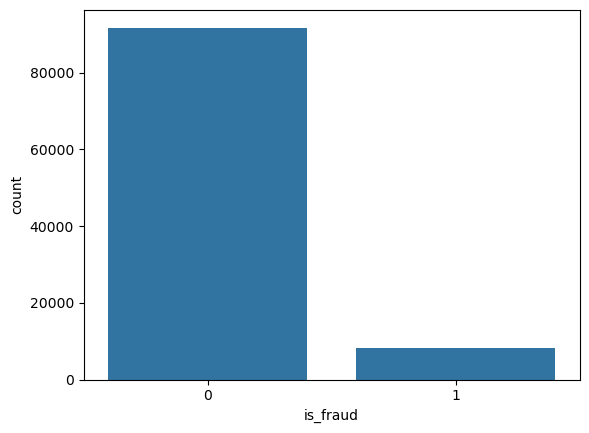

In [50]:
# Analyser la distribution de la variable cible
df2['is_fraud'].value_counts()
# Afficher le graphique de distribution de la variable cible
sns.countplot(x='is_fraud', data=df2)



Dans ce graphique :
- la barre correspondant à la valeur 0 représente le nombre de transactions normales (non frauduleuses),
- la barre correspondant à la valeur 1 représente le nombre de transactions frauduleuses.
  
L’analyse de la variable cible met en évidence un déséquilibre des classes, les transactions frauduleuses représentant une proportion significativement plus faible que les transactions légitimes.

 ## **Sélection de données ( liste des variables utiles pour ce projet)**

Une étape de sélection des variables a été réalisée afin de conserver uniquement les attributs les plus pertinents pour la détection de fraude bancaire ainsi que pour l évaluation de l impact de l’enrichissement par score de risque IP.
L’objectif de cette étape n’était pas d’exploiter exhaustivement l’ensemble des variables disponibles dans le dataset, mais de retenir les caractéristiques les plus cohérentes avec la problématique étudiée et l’hypothèse scientifique du projet.
Les variables sélectionnées couvrent principalement :
- les caractéristiques transactionnelles,
- les dimensions comportementales,
- les signaux temporels,
- ainsi que les mécanismes d’enrichissement externe basés sur la réputation IP.

| Variable | Type | Rôle antifraude |
|---|---|---|
| timestamp_utc | Temporelle | Analyse temporelle des transactions et détection des comportements inhabituels |
| amount_aed | Transactionnelle | Détection des montants atypiques et des anomalies financières |
| items_count | Transactionnelle | Analyse des paniers atypiques et des achats massifs |
| avg_item_price | Transactionnelle | Vérification de la cohérence du panier d’achat et détection des comportements inhabituels |
| ip_risk_score | Enrichissement externe | Évaluation du niveau de risque réseau associé à l’adresse IP utilisée lors de la transaction |
| is_fraud | Variable cible | Indique si la transaction est légitime (0) ou frauduleuse (1) |
| transactions_last_24h | Temporelle | Analyse de la fréquence transactionnelle | 
| transactions_last_1h | Temporelle | Détection des activités rapides ou automatisées |
|payment_method|Comportementale|Analyse des méthodes de paiement utilisées et identification des moyens de paiement associés à des comportements potentiellement frauduleux|

In [51]:
selected_columns = [
    'timestamp_utc',
    'transactions_last_24h',
    'transactions_last_1h',
    'amount_aed',
    'payment_method',
    'items_count',
    'avg_item_price',
    'ip_risk_score',
    'is_fraud'
]

df_selected = df2[selected_columns].copy()


## **Nettoyage des données, mise à l'échelle et transformation des données**

In [52]:
print("Nombre de lignes dupliquées :", df2.duplicated().sum())

Nombre de lignes dupliquées : 0


Une étape de mise à l’échelle des données numériques a été réalisée car les variables utilisées présentent des amplitudes très différentes. Par exemple, amount_aed peut atteindre plusieurs milliers d’unités alors que items_count ou transactions_last_24h prennent des valeurs beaucoup plus faibles.
Sans normalisation, les variables ayant les plus grandes valeurs pourraient influencer de manière disproportionnée l’apprentissage des modèles. Le scaling permet ainsi d’harmoniser les échelles des variables numériques et d’améliorer les performances des algorithmes sensibles aux différences d’amplitude.

# Transformation du timestamp
La variable timestamp_utc a été transformée car les modèles de machine learning n'exploitent pas efficacement une date brute. J'ai extrait l'heure de la transaction et le jour de la semaine afin de capturer d'éventuels comportements frauduleux liés au temps.

In [53]:

selected_columns = [
    'timestamp_utc',
    'transactions_last_24h',
    'transactions_last_1h',
    'amount_aed',
    'payment_method',
    'items_count',
    'avg_item_price',
    'ip_risk_score',
    'is_fraud'
]

df_selected = df2[selected_columns].copy()


# Transformation du timestamp


df_selected['timestamp_utc'] = pd.to_datetime(
    df_selected['timestamp_utc']
)

df_selected['hour'] = (
    df_selected['timestamp_utc'].dt.hour
)

df_selected['day_of_week'] = (
    df_selected['timestamp_utc'].dt.dayofweek
)
# Suppression du timestamp brut

df_without_timestamp = df_selected.drop(
    columns=['timestamp_utc']
)

# Encodage catégoriel
La variable payment_method étant de nature catégorielle, elle a été transformée en variables binaires grâce à la technique du One-Hot Encoding. Cette transformation permet aux algorithmes de machine learning d'exploiter l'information contenue dans les modes de paiement sans créer de relation d'ordre artificielle entre les catégories.


In [54]:
# Encodage catégoriel

df_without_timestamp = pd.get_dummies(
    df_without_timestamp,
    columns=['payment_method'],
    drop_first=True,
    dtype=int
)


# Variables numériques à scaler

In [55]:

numeric_features = [
    'amount_aed',
    'transactions_last_24h',
    'transactions_last_1h',
    'items_count',
    'avg_item_price',
    'ip_risk_score',
    'hour',
    'day_of_week'
]

# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_without_timestamp[numeric_features] = scaler.fit_transform(
    df_without_timestamp[numeric_features]
)

# Vérification finale

df_without_timestamp.head()

,transactions_last_24h,transactions_last_1h,amount_aed,items_count,avg_item_price,ip_risk_score,is_fraud,hour,day_of_week,payment_method_bank_transfer,payment_method_card,payment_method_google_pay,payment_method_paypal
0,-0.0961,-0.020253,-0.227813,0.733274,-0.281631,-0.274089,0,-1.657394,-1.4906,0,1,0,0
1,-0.0961,-0.020253,-0.230854,-1.090201,-0.097515,-0.583569,0,-1.657394,-1.4906,0,1,0,0
2,-0.0961,-0.020253,-0.116192,-0.178463,-0.145616,-0.431863,0,-1.657394,-1.4906,1,0,0,0
3,-0.0961,-0.020253,-0.158169,-0.178463,-0.179005,-0.577501,0,-1.657394,-1.4906,0,0,0,0
4,-0.0961,-0.020253,0.913647,-0.178463,0.673569,-1.293553,0,-1.657394,-1.4906,0,1,0,0


 ## **Séparation des variables**

# Variable externe : ip_risk_score
La variable ip_risk_score a été isolée en tant que variable externe, car elle représente une information de risque déjà calculée en amont à partir de l’adresse IP de l’utilisateur. Contrairement aux autres variables directement issues de la transaction, elle constitue un indicateur de risque externe pouvant être analysé séparément afin d’évaluer sa contribution spécifique à la détection de fraude.

In [56]:

# Variable externe

external_feature = [
    'ip_risk_score'
]

# Variables transactionnelles

In [57]:

# Variables transactionnelles

transactional_features = [
    'transactions_last_24h',
    'transactions_last_1h',
    'amount_aed',
    'items_count',
    'hour',
    'day_of_week',
    'avg_item_price'
]

# Variables de paiement encodées

payment_features = [
    col for col in df_without_timestamp.columns
    if 'payment_method_' in col
]


# Variable cible

target = 'is_fraud'

# Colonnes finales sélectionnées

selected_columns = (
    transactional_features
    + payment_features
    + [target]
)

# Création du dataset final

df_selected = df_without_timestamp[selected_columns]

# Affichage du résultat
df_selected.head()

,transactions_last_24h,transactions_last_1h,amount_aed,items_count,hour,day_of_week,avg_item_price,payment_method_bank_transfer,payment_method_card,payment_method_google_pay,payment_method_paypal,is_fraud
0,-0.0961,-0.020253,-0.227813,0.733274,-1.657394,-1.4906,-0.281631,0,1,0,0,0
1,-0.0961,-0.020253,-0.230854,-1.090201,-1.657394,-1.4906,-0.097515,0,1,0,0,0
2,-0.0961,-0.020253,-0.116192,-0.178463,-1.657394,-1.4906,-0.145616,1,0,0,0,0
3,-0.0961,-0.020253,-0.158169,-0.178463,-1.657394,-1.4906,-0.179005,0,0,0,0,0
4,-0.0961,-0.020253,0.913647,-0.178463,-1.657394,-1.4906,0.673569,0,1,0,0,0


# **Préparation des données pour l’apprentissage et l’évaluation du modèle**
Cette étape consiste à séparer les variables explicatives (X) de la variable cible (y), qui indique si une transaction est frauduleuse ou non. Le jeu de données est ensuite divisé en un ensemble d’entraînement (70 %) destiné à l’apprentissage du modèle et un ensemble de test (30 %) utilisé pour évaluer ses performances sur des données non vues. Le paramètre stratify permet de conserver la proportion initiale des transactions frauduleuses et non frauduleuses dans chaque sous-ensemble, tandis que random_state garantit la reproductibilité des résultats.

In [58]:

# Séparation des variables explicatives (X)
# et de la variable cible (y)

X = df_selected.drop(columns=['is_fraud'])

y = df_selected['is_fraud']

# Division du dataset
# en jeu d'entraînement et jeu de test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% pour le test
    random_state=42,    # reproductibilité des résultats
    stratify=y          # conservation de la proportion fraude/non fraude
)

# Vérification des dimensions

print("Taille du jeu d'entraînement :", X_train.shape)
print("Taille du jeu de test :", X_test.shape)

print("Taille y_train :", y_train.shape)
print("Taille y_test :", y_test.shape)

Taille du jeu d'entraînement : (70000, 11)
Taille du jeu de test : (30000, 11)
Taille y_train : (70000,)
Taille y_test : (30000,)


## **Test du modèle Random Forest**

In [198]:

# Test du modèle Random Forest

# Création du modèle

rf_model = RandomForestClassifier(
    n_estimators=100,   # Nombre d’arbres de décision
    max_depth=10,       # Profondeur maximale des arbres
    random_state=42,     # Reproductibilité des résultats
  class_weight='balanced'  # Donner plus d’importance aux transactions frauduleuses
)


## Entraînement du modèle baseline

In [199]:
rf_model.fit(X_train, y_train)

# Confirmation

print("Le modèle Random Forest a été entraîné avec succès.")

Le modèle Random Forest a été entraîné avec succès.


  ## Prédictions

In [200]:
y_pred = rf_model.predict(X_test)
print(y_pred[:10])

[0 1 1 0 0 0 0 0 0 0]


## les probabilités de fraude

In [201]:
# Probabilité d’appartenir à la classe fraude
y_proba = rf_model.predict_proba(X_test)
# Affichage des 10 premières probabilités
print(y_proba[:10])

[[0.55177775 0.44822225]
 [0.47227399 0.52772601]
 [0.49494602 0.50505398]
 [0.51441737 0.48558263]
 [0.51949999 0.48050001]
 [0.50852585 0.49147415]
 [0.52721239 0.47278761]
 [0.50169297 0.49830703]
 [0.51772764 0.48227236]
 [0.52152493 0.47847507]]


Par défaut, les algorithmes de classification de Scikit-Learn utilisent généralement un seuil de décision fixé à 0.5 pour déterminer si une transaction est considérée comme frauduleuse ou non.
une transaction présentant une probabilité de fraude de 0.36 sera classée comme légitime, car le score reste inférieur au seuil de 0.5 ;
une transaction présentant une probabilité de fraude de 0.59 sera classée comme frauduleuse, car le score dépasse le seuil défini.

  ## Mesures d'évaluation

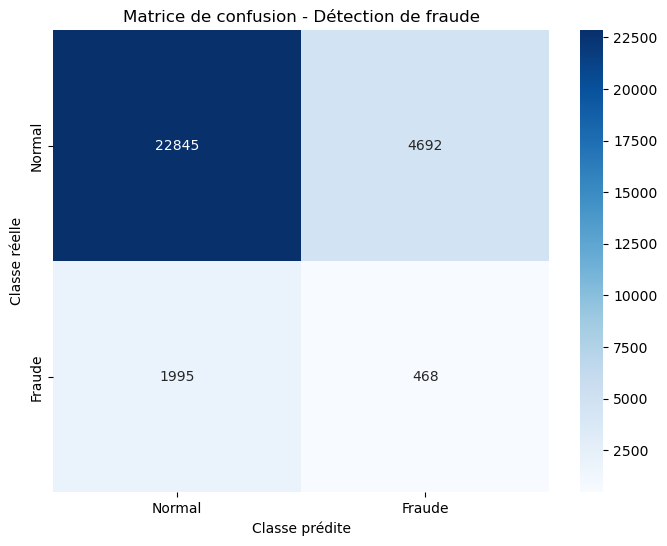

ROC-AUC : 0.5012803207188952
========== Rapport de classification ==========
              precision    recall  f1-score   support

           0       0.92      0.83      0.87     27537
           1       0.09      0.19      0.12      2463

    accuracy                           0.78     30000
   macro avg       0.51      0.51      0.50     30000
weighted avg       0.85      0.78      0.81     30000

========== Métriques principales ==========
Accuracy : 0.7771
Precision : 0.09069767441860466
Recall : 0.1900121802679659
F1-score : 0.12278630460448642
ROC-AUC : 0.5012803207188952

Métriques Random Forest Baseline enregistrées


In [202]:

# ======================================
# Affichage de la matrice de confusion
# ======================================
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=['Normal', 'Fraude'],
    yticklabels=['Normal', 'Fraude']
)

plt.xlabel('Classe prédite')

plt.ylabel('Classe réelle')

plt.title('Matrice de confusion - Détection de fraude')

plt.show()

# ======================================
# Calcul des métriques de classification
# ======================================
# Prédictions finales
y_pred = rf_model.predict(X_test)

# Probabilités de fraude
y_prob = rf_model.predict_proba(X_test)[:,1]

# Calcul ROC-AUC
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC :", auc)
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)


# ======================================
# Affichage des résultats
# ======================================

print("========== Rapport de classification ==========")

print(classification_report(y_test, y_pred))


print("========== Métriques principales ==========")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1-score :", f1)

print("ROC-AUC :", auc)

# ======================================
# Sauvegarde des métriques RF Baseline
# ======================================

precision_rf_base = precision
recall_rf_base = recall
f1_rf_base = f1
auc_rf_base = auc


print("\nMétriques Random Forest Baseline enregistrées")


L’utilisation du rééquilibrage des classes a permis d’améliorer significativement la capacité du modèle à détecter les transactions frauduleuses, comme le montre l’augmentation importante du Recall. En contrepartie, la précision diminue et le nombre de faux positifs augmente, ce qui constitue un comportement fréquent dans les problématiques de détection de fraude.

## **Construction du jeu de données enrichi par une variable de risque externe (ip_risk_score)**

In [170]:
# ======================================
# Colonnes avec la variable supplementaire ip_risk_score
# ======================================

X_enriched = df_without_timestamp[
    transactional_features
    + payment_features
    + external_feature
    + [target]
]

# ======================================
# Affichage du résultat
# ======================================

X_enriched.head()

,transactions_last_24h,transactions_last_1h,amount_aed,items_count,hour,day_of_week,avg_item_price,payment_method_bank_transfer,payment_method_card,payment_method_google_pay,payment_method_paypal,ip_risk_score,is_fraud
0,-0.0961,-0.020253,-0.227813,0.733274,-1.657394,-1.4906,-0.281631,0,1,0,0,-0.274089,0
1,-0.0961,-0.020253,-0.230854,-1.090201,-1.657394,-1.4906,-0.097515,0,1,0,0,-0.583569,0
2,-0.0961,-0.020253,-0.116192,-0.178463,-1.657394,-1.4906,-0.145616,1,0,0,0,-0.431863,0
3,-0.0961,-0.020253,-0.158169,-0.178463,-1.657394,-1.4906,-0.179005,0,0,0,0,-0.577501,0
4,-0.0961,-0.020253,0.913647,-0.178463,-1.657394,-1.4906,0.673569,0,1,0,0,-1.293553,0


In [171]:
# ======================================
# Séparation des variables explicatives (X)
# et de la variable cible (y)
# ======================================

X = X_enriched.drop(columns=['is_fraud'])

y = X_enriched['is_fraud']


# ======================================
# Division du dataset
# en jeu d'entraînement et jeu de test
# ======================================

X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% pour le test
    random_state=42,    # reproductibilité des résultats
    stratify=y          # conservation de la proportion fraude/non fraude
)


# ======================================
# Vérification des dimensions
# ======================================

print("Taille du jeu d'entraînement :", X_train_en.shape)
print("Taille du jeu de test :", X_test_en.shape)

print("Taille y_train :", y_train_en.shape)
print("Taille y_test :", y_test_en.shape)

Taille du jeu d'entraînement : (70000, 12)
Taille du jeu de test : (30000, 12)
Taille y_train : (70000,)
Taille y_test : (30000,)


## Entraînement du modèle enrichi

In [205]:

# ======================================
# Test du modèle Random Forest
# ======================================
from sklearn.ensemble import RandomForestClassifier
# ======================================
# Création du modèle
# ======================================
rf_model_enrichi = RandomForestClassifier(
    n_estimators=100,   # Nombre d’arbres de décision
    max_depth=10,       # Profondeur maximale des arbres
    random_state=42,     # Reproductibilité des résultats
  class_weight='balanced'  # Donner plus d’importance aux transactions frauduleuses
)
rf_model_enrichi.fit(X_train_en, y_train_en)
# ======================================
# Confirmation
# ======================================

print("Le modèle Random Forest a été entraîné avec succès.")

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


[0 0 0 0 0 1 1 1 1 0]


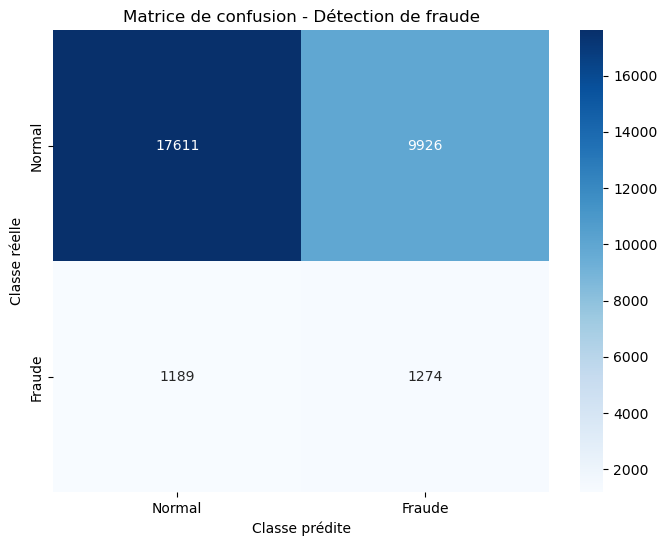

========== Rapport de classification ==========
              precision    recall  f1-score   support

           0       0.92      0.83      0.87     27537
           1       0.09      0.19      0.12      2463

    accuracy                           0.78     30000
   macro avg       0.51      0.51      0.50     30000
weighted avg       0.85      0.78      0.81     30000

========== Métriques principales ==========
Accuracy : 0.7771
Precision : 0.09069767441860466
Recall : 0.5172553796183516
F1-score : 0.18648905803996194
ROC-AUC : 0.6127046707363691

Métriques Random Forest Enrichi enregistrées


In [211]:
y_pred_enrichi = rf_model_enrichi.predict(X_test_en)
print(y_pred_enrichi[:10])

# ======================================
# Affichage de la matrice de confusion
# ======================================
conf_matrix = confusion_matrix(y_test_en, y_pred_enrichi)
plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=['Normal', 'Fraude'],
    yticklabels=['Normal', 'Fraude']
)

plt.xlabel('Classe prédite')

plt.ylabel('Classe réelle')

plt.title('Matrice de confusion - Détection de fraude')

plt.show()

# ======================================
# Calcul des métriques de classification
# Modèle enrichi avec ip_risk_score
# ======================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


recall = recall_score(
    y_test_en,
    y_pred_enrichi
)

f1 = f1_score(
    y_test_en,
    y_pred_enrichi
)

auc = roc_auc_score(
    y_test_en,
    y_prob_enrichi
)


# ======================================
# Affichage des résultats
# ======================================

print("========== Rapport de classification ==========")

print(classification_report(y_test, y_pred))


print("========== Métriques principales ==========")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1-score :", f1)

print("ROC-AUC :", auc)
# ======================================
# Sauvegarde des métriques RF Enrichi
# ======================================

precision_rf_en = precision
recall_rf_en = recall
f1_rf_en = f1
auc_rf_en = auc

print("\nMétriques Random Forest Enrichi enregistrées")


Les résultats obtenus montrent une amélioration significative des performances du modèle après intégration du score externe de réputation IP. Le modèle enrichi présente une augmentation importante du Recall, de la Precision et du F1-score, démontrant l’intérêt des mécanismes d’enrichissement externe dans les systèmes de détection de fraude bancaire.

# **Model Logistic Regression**

In [174]:
# ======================================
# Création du dataset baseline
# ======================================
# Le modèle baseline utilise uniquement
# les variables transactionnelles
# et les variables liées au paiement.
# Le score externe ip_risk_score
# n'est pas encore intégré à cette étape.

X_baseline = df_without_timestamp[
    transactional_features
    + payment_features
]


# ======================================
# Variable cible
# ======================================
# La variable cible indique :
# 0 = transaction normale
# 1 = transaction frauduleuse

y_baseline = df_without_timestamp['is_fraud']


# ======================================
# Division du dataset
# en jeu d'entraînement et jeu de test
# ======================================

from sklearn.model_selection import train_test_split

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline,
    y_baseline,
    test_size=0.3,       # 30% des données utilisées pour le test
    random_state=42,     # reproductibilité des résultats
    stratify=y_baseline  # conservation du ratio fraude/non fraude
)


# ======================================
# Création du modèle baseline
# ======================================
# La régression logistique est utilisée
# comme modèle de classification supervisée.
#
# class_weight='balanced'
# permet de mieux gérer
# le déséquilibre des classes.

logistic_model_base = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)


# ======================================
# Entraînement du modèle
# ======================================

logistic_model_base.fit(
    X_train_base,
    y_train_base
)


# ======================================
# Prédictions finales
# ======================================
# Le modèle prédit :
# 0 = transaction normale
# 1 = transaction frauduleuse

y_pred_base = logistic_model_base.predict(
    X_test_base
)


# ======================================
# Probabilités de fraude
# ======================================
# predict_proba retourne :
# [P(non fraude), P(fraude)]
#
# [:,1] permet de récupérer
# uniquement la probabilité de fraude.

y_prob_base = logistic_model_base.predict_proba(
    X_test_base
)[:,1]

In [155]:
# ======================================
# Évaluation du modèle baseline
# ======================================

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(
    classification_report(
        y_test_base,
        y_pred_base
    )
)

# ======================================
# Calcul des métriques
# ======================================

accuracy_lr_base = accuracy_score(
    y_test_base,
    y_pred_base
)

precision_lr_base = precision_score(
    y_test_base,
    y_pred_base
)

recall_lr_base = recall_score(
    y_test_base,
    y_pred_base
)

f1_lr_base = f1_score(
    y_test_base,
    y_pred_base
)

auc_lr_base = roc_auc_score(
    y_test_base,
    y_prob_base
)

# ======================================
# Affichage
# ======================================

print("Accuracy :", accuracy_lr_base)
print("Precision :", precision_lr_base)
print("Recall :", recall_lr_base)
print("F1-score :", f1_lr_base)
print("ROC-AUC :", auc_lr_base)

# ======================================
# Confirmation
# ======================================

print("\nMétriques Logistic Regression Baseline enregistrées")

              precision    recall  f1-score   support

           0       0.92      0.59      0.72     27537
           1       0.09      0.45      0.15      2463

    accuracy                           0.58     30000
   macro avg       0.51      0.52      0.43     30000
weighted avg       0.85      0.58      0.67     30000

Accuracy : 0.5751
Precision : 0.0885741718674988
Recall : 0.44945188794153473
F1-score : 0.14798476037698013
ROC-AUC : 0.515592566844438

Métriques Logistic Regression Baseline enregistrées


# **Logistic Regression enrichi**

In [184]:
# ======================================
# Création du modèle
# ======================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

# ======================================
# Entraînement du modèle
# ======================================

logistic_model.fit(
    X_train_en,
    y_train_en
)

# ======================================
# Prédictions finales
# ======================================

y_pred_logistic = logistic_model.predict(
    X_test_en
)

# ======================================
# Probabilités de fraude
# ======================================

y_prob_logistic = logistic_model.predict_proba(
    X_test_en
)[:,1]

# ======================================
# Rapport de classification
# ======================================

print(
    classification_report(
        y_test_en,
        y_pred_logistic
    )
)

# ======================================
# Calcul des métriques
# ======================================

accuracy_lr_en = accuracy_score(
    y_test_en,
    y_pred_logistic
)

precision_lr_en = precision_score(
    y_test_en,
    y_pred_logistic
)

recall_lr_en = recall_score(
    y_test_en,
    y_pred_logistic
)

f1_lr_en = f1_score(
    y_test_en,
    y_pred_logistic
)

auc_lr_en = roc_auc_score(
    y_test_en,
    y_prob_logistic
)

# ======================================
# Affichage des métriques
# ======================================

print("Accuracy :", accuracy_lr_en)
print("Precision :", precision_lr_en)
print("Recall :", recall_lr_en)
print("F1-score :", f1_lr_en)
print("ROC-AUC :", auc_lr_en)

# ======================================
# Confirmation
# ======================================

print("\nMétriques Logistic Regression enrichi enregistrées")

              precision    recall  f1-score   support

           0       0.94      0.59      0.73     27537
           1       0.11      0.59      0.19      2463

    accuracy                           0.59     30000
   macro avg       0.53      0.59      0.46     30000
weighted avg       0.87      0.59      0.68     30000

Accuracy : 0.5923666666666667
Precision : 0.11417509481668774
Recall : 0.5866829070239545
F1-score : 0.1911502083471129
ROC-AUC : 0.629643641461779

Métriques Logistic Regression enrichi enregistrées


L’intégration du score externe de réputation IP améliore les performances de la régression logistique, notamment au niveau du Recall et du score ROC-AUC. Ces résultats montrent que l’enrichissement externe apporte des signaux discriminants supplémentaires pour la détection des transactions frauduleuses, même avec un modèle linéaire relativement simple.

# **Modèle Decision Tree**

In [213]:
# ======================================
# Decision Tree Classifier
# ======================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ======================================
# Création du modèle
# ======================================

dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
     class_weight='balanced',
    random_state=42
    
)

# ======================================
# Entraînement
# ======================================

dt_model.fit(
    X_train_base,
    y_train_base
)

# ======================================
# Prédictions
# ======================================

y_pred_dt = dt_model.predict(
    X_test_base
)

y_prob_dt = dt_model.predict_proba(
    X_test_base
)[:,1]

# ======================================
# Calcul des métriques
# ======================================

precision_dt_base = precision_score(
    y_test_base,
    y_pred_dt
)

recall_dt_base = recall_score(
    y_test_base,
    y_pred_dt
)

f1_dt_base = f1_score(
    y_test_base,
    y_pred_dt
)

auc_dt_base = roc_auc_score(
    y_test_base,
    y_prob_dt
)

# ======================================
# Rapport de classification
# ======================================

print(
    classification_report(
        y_test_base,
        y_pred_dt
    )
)

print("Precision DT :", precision_dt_base)
print("Recall DT :", recall_dt_base)
print("F1 DT :", f1_dt_base)
print("ROC-AUC DT :", auc_dt_base)

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     27537
           1       0.09      0.36      0.15      2463

    accuracy                           0.66     30000
   macro avg       0.51      0.53      0.47     30000
weighted avg       0.86      0.66      0.74     30000

Precision DT : 0.09445498629559351
Recall DT : 0.3637840032480715
F1 DT : 0.14997070884592853
ROC-AUC DT : 0.5220636889817946


In [214]:
# ======================================
# Decision Tree Enrichi
# ======================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ======================================
# Création du modèle
# ======================================

dt_model_en = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
     class_weight='balanced',
    random_state=42
)

# ======================================
# Entraînement
# ======================================

dt_model_en.fit(
    X_train_en,
    y_train_en
)

# ======================================
# Prédictions
# ======================================

y_pred_dt_en = dt_model_en.predict(
    X_test_en
)

y_prob_dt_en = dt_model_en.predict_proba(
    X_test_en
)[:,1]

# ======================================
# Calcul des métriques
# ======================================

precision_dt_en = precision_score(
    y_test_en,
    y_pred_dt_en
)

recall_dt_en = recall_score(
    y_test_en,
    y_pred_dt_en
)

f1_dt_en = f1_score(
    y_test_en,
    y_pred_dt_en
)

auc_dt_en = roc_auc_score(
    y_test_en,
    y_prob_dt_en
)

# ======================================
# Rapport de classification
# ======================================

print(
    classification_report(
        y_test_en,
        y_pred_dt_en
    )
)

print("Precision DT enrichi :", precision_dt_en)
print("Recall DT enrichi :", recall_dt_en)
print("F1 DT enrichi :", f1_dt_en)
print("ROC-AUC DT enrichi :", auc_dt_en)

              precision    recall  f1-score   support

           0       0.94      0.57      0.71     27537
           1       0.11      0.59      0.18      2463

    accuracy                           0.57     30000
   macro avg       0.52      0.58      0.44     30000
weighted avg       0.87      0.57      0.66     30000

Precision DT enrichi : 0.10862120309708159
Recall DT enrichi : 0.5923670320747056
F1 DT enrichi : 0.1835797420572507
ROC-AUC DT enrichi : 0.6096802897503378


# **KNN Baseline**

In [220]:
# ======================================
# KNN Baseline
# ======================================

from sklearn.neighbors import KNeighborsClassifier

knn_base = KNeighborsClassifier(
    n_neighbors=5
)

knn_base.fit(
    X_train_base,
    y_train_base
)

print("KNN Baseline entraîné")

KNN Baseline entraîné


In [221]:
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Prédictions

y_pred_knn_base = knn_base.predict(
    X_test_base
)

# Probabilités

y_prob_knn_base = knn_base.predict_proba(
    X_test_base
)[:,1]

# Métriques

precision_knn_base = precision_score(
    y_test_base,
    y_pred_knn_base
)

recall_knn_base = recall_score(
    y_test_base,
    y_pred_knn_base
)

f1_knn_base = f1_score(
    y_test_base,
    y_pred_knn_base
)

auc_knn_base = roc_auc_score(
    y_test_base,
    y_prob_knn_base
)

print(
    classification_report(
        y_test_base,
        y_pred_knn_base
    )
)

print("Precision :", precision_knn_base)
print("Recall :", recall_knn_base)
print("F1-score :", f1_knn_base)
print("ROC-AUC :", auc_knn_base)

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     27537
           1       0.07      0.00      0.01      2463

    accuracy                           0.91     30000
   macro avg       0.49      0.50      0.48     30000
weighted avg       0.85      0.91      0.88     30000

Precision : 0.06818181818181818
Recall : 0.0048721071863581
F1-score : 0.00909435392194013
ROC-AUC : 0.5045694545607562


# **KNN Baseline enrichi**

In [222]:
# ======================================
# KNN Enrichi
# ======================================

knn_en = KNeighborsClassifier(
    n_neighbors=5
)

knn_en.fit(
    X_train_en,
    y_train_en
)

print("KNN Enrichi entraîné")

KNN Enrichi entraîné


In [223]:
# Prédictions

y_pred_knn_en = knn_en.predict(
    X_test_en
)

# Probabilités

y_prob_knn_en = knn_en.predict_proba(
    X_test_en
)[:,1]

# Métriques

precision_knn_en = precision_score(
    y_test_en,
    y_pred_knn_en
)

recall_knn_en = recall_score(
    y_test_en,
    y_pred_knn_en
)

f1_knn_en = f1_score(
    y_test_en,
    y_pred_knn_en
)

auc_knn_en = roc_auc_score(
    y_test_en,
    y_prob_knn_en
)

print(
    classification_report(
        y_test_en,
        y_pred_knn_en
    )
)

print("Precision :", precision_knn_en)
print("Recall :", recall_knn_en)
print("F1-score :", f1_knn_en)
print("ROC-AUC :", auc_knn_en)

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     27537
           1       0.07      0.01      0.01      2463

    accuracy                           0.91     30000
   macro avg       0.49      0.50      0.48     30000
weighted avg       0.85      0.91      0.88     30000

Precision : 0.06842105263157895
Recall : 0.005278116118554608
F1-score : 0.00980022615906521
ROC-AUC : 0.5280308938340385


In [224]:
#  KNN Baseline
precision_knn_base
recall_knn_base
f1_knn_base
auc_knn_base

precision_knn_en
recall_knn_en
f1_knn_en
auc_knn_en

# Logistic Regression
precision_lr_base
recall_lr_base
f1_lr_base
auc_lr_base

precision_lr_en
recall_lr_en
f1_lr_en
auc_lr_en

# Decision Tree
precision_dt_base
recall_dt_base
f1_dt_base
auc_dt_base

precision_dt_en
recall_dt_en
f1_dt_en
auc_dt_en

# Random Forest
precision_rf_base
recall_rf_base
f1_rf_base
auc_rf_base

precision_rf_en
recall_rf_en
f1_rf_en
auc_rf_en

0.6262182792897065

In [227]:
# ======================================
# Tableau comparatif global
# ======================================

import pandas as pd

results_df = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Logistic Regression',

        'Decision Tree',
        'Decision Tree',

        'Random Forest',
        'Random Forest',

        'KNN',
        'KNN'
    ],

    'Version': [
        'Baseline',
        'Enrichi',

        'Baseline',
        'Enrichi',

        'Baseline',
        'Enrichi',

        'Baseline',
        'Enrichi'
    ],

    'Precision': [
        precision_lr_base,
        precision_lr_en,

        precision_dt_base,
        precision_dt_en,

        precision_rf_base,
        precision_rf_en,

        precision_knn_base,
        precision_knn_en
    ],

    'Recall': [
        recall_lr_base,
        recall_lr_en,

        recall_dt_base,
        recall_dt_en,

        recall_rf_base,
        recall_rf_en,

        recall_knn_base,
        recall_knn_en
    ],

    'F1_score': [
        f1_lr_base,
        f1_lr_en,

        f1_dt_base,
        f1_dt_en,

        f1_rf_base,
        f1_rf_en,

        f1_knn_base,
        f1_knn_en
    ],

    'ROC_AUC': [
        auc_lr_base,
        auc_lr_en,

        auc_dt_base,
        auc_dt_en,

        auc_rf_base,
        auc_rf_en,

        auc_knn_base,
        auc_knn_en
    ]
})

# Arrondi à 3 décimales

results_df = results_df.round(3)

print("Comparaison des performances des modèles")

display(results_df)

Comparaison des performances des modèles


,Model,Version,Precision,Recall,F1_score,ROC_AUC
0,Logistic Regression,Baseline,0.089,0.449,0.148,0.516
1,Logistic Regression,Enrichi,0.114,0.587,0.191,0.630
2,Decision Tree,Baseline,0.094,0.364,0.150,0.522
3,Decision Tree,Enrichi,0.109,0.592,0.184,0.610
4,Random Forest,Baseline,0.091,0.190,0.123,0.501
5,Random Forest,Enrichi,0.091,0.517,0.186,0.613
6,KNN,Baseline,0.068,0.005,0.009,0.505
7,KNN,Enrichi,0.068,0.005,0.010,0.528


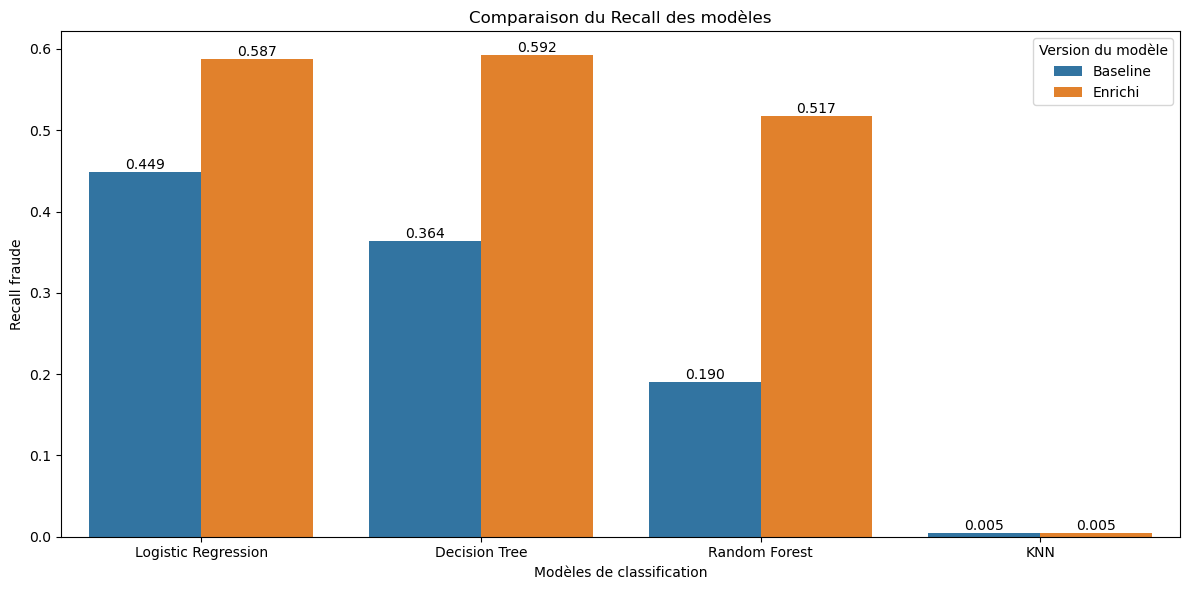

In [228]:
# ======================================
# Graphique Recall
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Recall',
    hue='Version'
)

plt.title(
    'Comparaison du Recall des modèles'
)

plt.ylabel(
    'Recall fraude'
)

plt.xlabel(
    'Modèles de classification'
)

plt.legend(
    title='Version du modèle'
)

# Affichage des valeurs sur les barres
for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt='%.3f'
    )

plt.tight_layout()

plt.show()

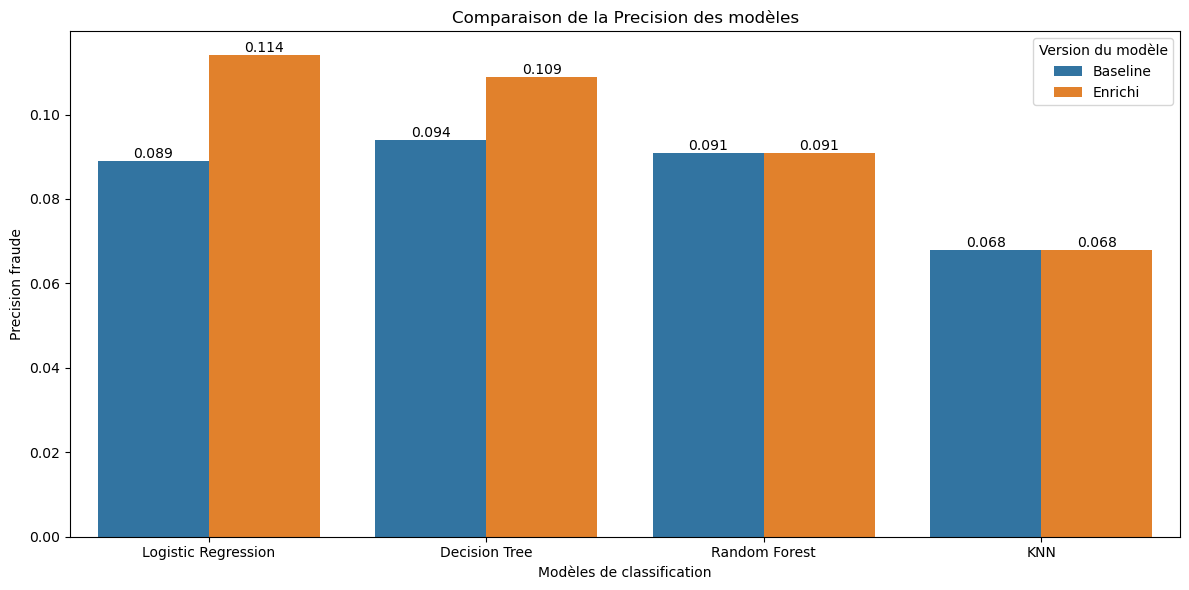

In [229]:
# ======================================
# Graphique Precision
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Precision',
    hue='Version'
)

plt.title(
    'Comparaison de la Precision des modèles'
)

plt.ylabel(
    'Precision fraude'
)

plt.xlabel(
    'Modèles de classification'
)

plt.legend(
    title='Version du modèle'
)

# Affichage des valeurs sur les barres
for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt='%.3f'
    )

plt.tight_layout()

plt.show()

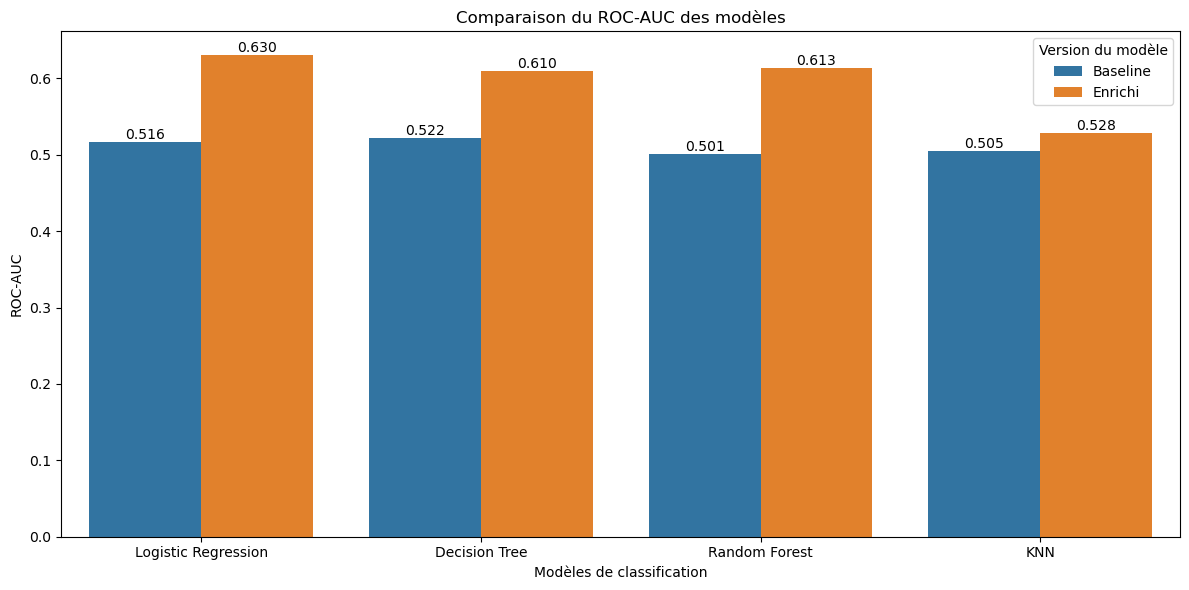

In [230]:
# ======================================
# Graphique ROC-AUC
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC_AUC',
    hue='Version'
)

plt.title(
    'Comparaison du ROC-AUC des modèles'
)

plt.ylabel(
    'ROC-AUC'
)

plt.xlabel(
    'Modèles de classification'
)

plt.legend(
    title='Version du modèle'
)

# Affichage des valeurs sur les barres
for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt='%.3f'
    )

plt.tight_layout()

plt.show()

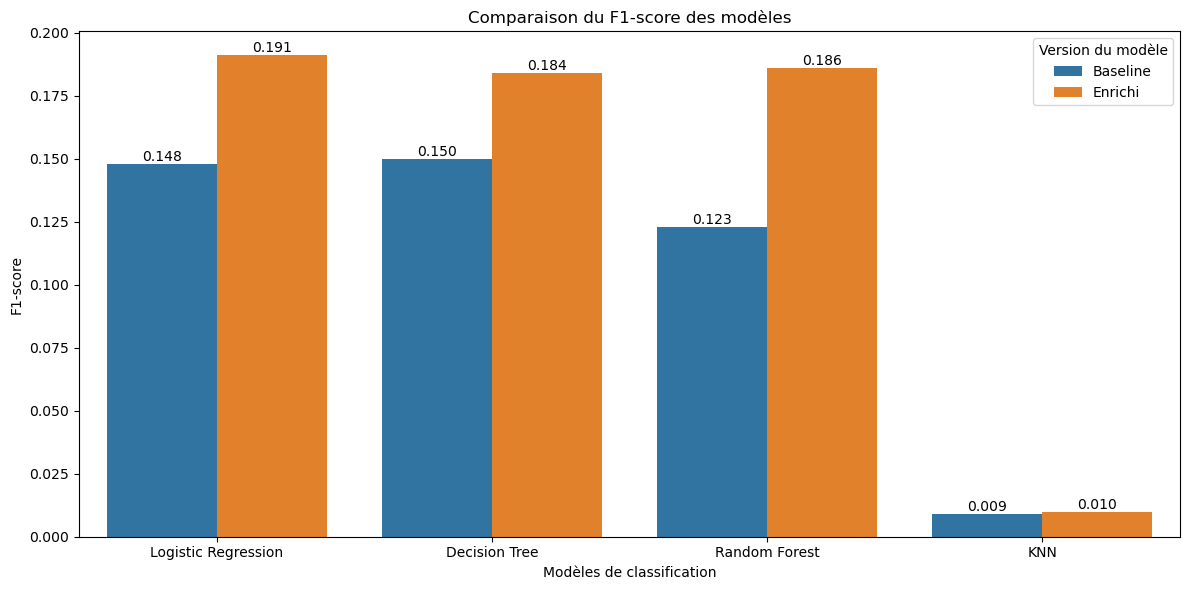

In [231]:
# ======================================
# Graphique F1-score
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1_score',
    hue='Version'
)

plt.title(
    'Comparaison du F1-score des modèles'
)

plt.ylabel(
    'F1-score'
)

plt.xlabel(
    'Modèles de classification'
)

plt.legend(
    title='Version du modèle'
)

# Affichage des valeurs sur les barres
for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt='%.3f'
    )

plt.tight_layout()

plt.show()